saved: /home/mariuszoslaw/uni/masters/Results/figures_calibration_comparison/SVM_calibration_comparison_30_features.pdf
saved: /home/mariuszoslaw/uni/masters/Results/figures_calibration_comparison/SVM_calibration_comparison_30_features.png


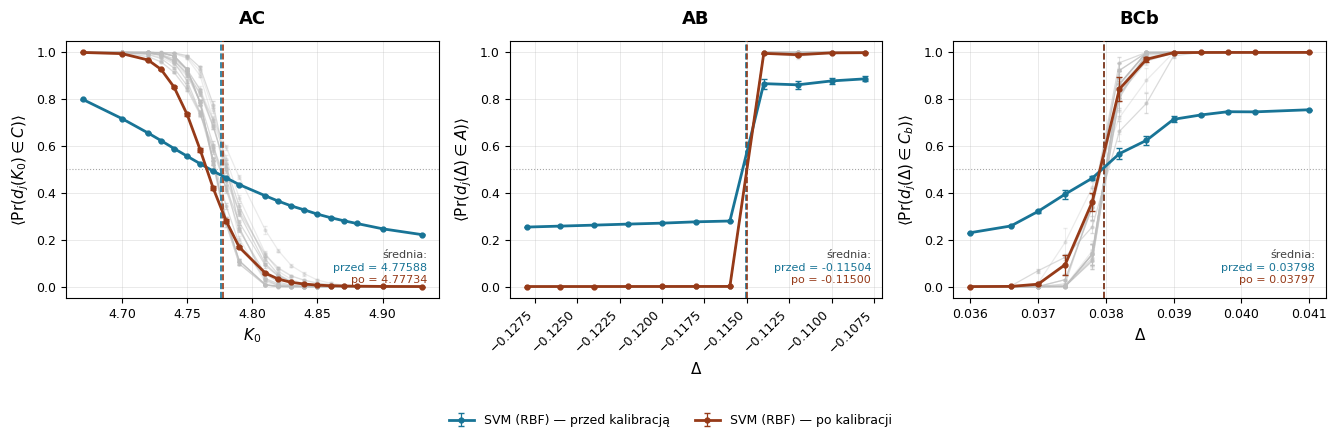

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# SETTINGS
# ============================================================

ROOT = Path(".").resolve()

OUTPUT_DIR = ROOT / "figures_calibration_comparison"

# Tylko 30 cech
FEATURE_SET = 30

# Porównywany model
TARGET_MODEL = "SVM (RBF)"

# Przed / po kalibracji
CALIBRATION_BEFORE = "uncalibrated"
CALIBRATION_AFTER = "calibrated"

FORMATS = ["pdf", "png"]
DPI = 300


# ============================================================
# COLORS
# ============================================================

# Wszystkie pozostałe modele
BACKGROUND_COLOR = "#BDBDBD"

# SVM
BEFORE_COLOR = "#187496"
AFTER_COLOR = "#963a18"

# Średnie
BEFORE_MEAN_COLOR = BEFORE_COLOR
AFTER_MEAN_COLOR = AFTER_COLOR


# ============================================================
# TRANSITIONS
# ============================================================

TRANSITIONS = {
    "AC": {
        "folder": "AC",
        "mean_file": "AC_curve_mean.csv",
        "summary_file": "AC_summary.csv",

        "x_column": "K0",
        "crit_column": "K0_crit",

        "xlabel": r"$K_0$",

        "ylabel": (
            r"$\langle \Pr(d_j(K_0)\in C)\rangle$"
        ),

        "title": "AC",

        # Zgodnie z drugim notebookiem:
        # A--C rysujemy jako 1 - p
        "invert_probability": True,
    },

    "AB": {
        "folder": "AB",
        "mean_file": "AB_curve_mean.csv",
        "summary_file": "AB_summary.csv",

        "x_column": "Delta",
        "crit_column": "Delta_crit",

        "xlabel": r"$\Delta$",

        "ylabel": (
            r"$\langle \Pr(d_j(\Delta)\in A)\rangle$"
        ),

        "title": "AB",

        # A--B również odwracamy
        "invert_probability": True,
    },

    "BCb": {
        "folder": "BCb",
        "mean_file": "BCb_curve_mean.csv",
        "summary_file": "BCb_summary.csv",

        "x_column": "Delta",
        "crit_column": "Delta_crit",

        "xlabel": r"$\Delta$",

        "ylabel": (
            r"$\langle \Pr(d_j(\Delta)\in C_b)\rangle$"
        ),

        "title": "BCb",

        # Tutaj zwykłe p
        "invert_probability": False,
    },
}


# ============================================================
# LOAD DATA
# ============================================================

def load_transition_data(
    root,
    transition,
):

    config = TRANSITIONS[transition]

    folder = (
        root
        / "SUPERVISED"
        / config["folder"]
    )

    mean_path = (
        folder
        / config["mean_file"]
    )

    summary_path = (
        folder
        / config["summary_file"]
    )

    if not mean_path.exists():
        raise FileNotFoundError(mean_path)

    if not summary_path.exists():
        raise FileNotFoundError(summary_path)

    mean_df = pd.read_csv(mean_path)

    summary_df = pd.read_csv(summary_path)

    return mean_df, summary_df


# ============================================================
# FILTER CURVE
# ============================================================

def filter_curve(
    df,
    model,
    calibration,
):

    result = df[
        (df["feature_set"] == FEATURE_SET)
        & (df["model"] == model)
        & (df["calibration"] == calibration)
    ].copy()

    return result


# ============================================================
# GET MEAN CRITICAL VALUE
# ============================================================

def get_mean_critical_value(
    summary_df,
    calibration,
    crit_column,
):

    result = summary_df[
        (summary_df["feature_set"] == FEATURE_SET)
        & (summary_df["calibration"] == calibration)
    ].copy()

    # Dokładnie takie samo filtrowanie modeli
    # jak w result_charts_features
    result = filter_supervised_models(result)

    values = pd.to_numeric(
        result[crit_column],
        errors="coerce",
    ).dropna()

    if values.empty:
        return np.nan

    return values.mean()
    
def filter_supervised_models(df):
    df = df.copy()

    keep = (
        (df["model"] == "Logistic Regression")
        |
        (df["model"] == "kNN")
        |
        (
            ~df["model"].str.startswith("Logistic Regression")
            &
            ~df["model"].str.startswith("kNN")
        )
    )

    return df[keep].copy()

# ============================================================
# PLOT ONE PANEL
# ============================================================

def plot_transition_panel(
    ax,
    mean_df,
    summary_df,
    transition,
):

    config = TRANSITIONS[transition]

    x_column = config["x_column"]
    crit_column = config["crit_column"]

    invert_probability = (
        config["invert_probability"]
    )


    # ========================================================
    # ALL OTHER MODELS
    # ========================================================

    models = (
        mean_df["model"]
        .dropna()
        .unique()
    )


    # --------------------------------------------------------
    # BEFORE CALIBRATION
    # --------------------------------------------------------

    for model in models:

        if model == TARGET_MODEL:
            continue

        curve = filter_curve(
            mean_df,
            model,
            CALIBRATION_BEFORE,
        )

        if curve.empty:
            continue

        curve = (
            curve
            .sort_values(x_column)
            .copy()
        )

        y = curve["mean"].to_numpy()

        if invert_probability:
            y = 1.0 - y

        ax.errorbar(
            curve[x_column],
            y,
            yerr=curve["mean_err"],
            fmt="o-",
            color=BACKGROUND_COLOR,
            ecolor=BACKGROUND_COLOR,
            markersize=2,
            linewidth=0.9,
            capsize=1.5,
            elinewidth=0.6,
            alpha=0.55,
            zorder=1,
        )


    # --------------------------------------------------------
    # AFTER CALIBRATION
    # --------------------------------------------------------

    for model in models:

        if model == TARGET_MODEL:
            continue

        curve = filter_curve(
            mean_df,
            model,
            CALIBRATION_AFTER,
        )

        if curve.empty:
            continue

        curve = (
            curve
            .sort_values(x_column)
            .copy()
        )

        y = curve["mean"].to_numpy()

        if invert_probability:
            y = 1.0 - y

        ax.errorbar(
            curve[x_column],
            y,
            yerr=curve["mean_err"],
            fmt="o-",
            color=BACKGROUND_COLOR,
            ecolor=BACKGROUND_COLOR,
            markersize=2,
            linewidth=0.9,
            capsize=1.5,
            elinewidth=0.6,
            alpha=0.30,
            zorder=1,
        )


    # ========================================================
    # SVM — BEFORE CALIBRATION
    # ========================================================

    svm_before = filter_curve(
        mean_df,
        TARGET_MODEL,
        CALIBRATION_BEFORE,
    )

    if not svm_before.empty:

        svm_before = (
            svm_before
            .sort_values(x_column)
            .copy()
        )

        y_before = (
            svm_before["mean"]
            .to_numpy()
        )

        if invert_probability:
            y_before = 1.0 - y_before

        ax.errorbar(
            svm_before[x_column],
            y_before,
            yerr=svm_before["mean_err"],
            fmt="o-",
            color=BEFORE_COLOR,
            ecolor=BEFORE_COLOR,
            markersize=3.5,
            linewidth=2.0,
            capsize=2.5,
            elinewidth=0.9,
            label="SVM (RBF) — przed kalibracją",
            zorder=4,
        )


    # ========================================================
    # SVM — AFTER CALIBRATION
    # ========================================================

    svm_after = filter_curve(
        mean_df,
        TARGET_MODEL,
        CALIBRATION_AFTER,
    )

    if not svm_after.empty:

        svm_after = (
            svm_after
            .sort_values(x_column)
            .copy()
        )

        y_after = (
            svm_after["mean"]
            .to_numpy()
        )

        if invert_probability:
            y_after = 1.0 - y_after

        ax.errorbar(
            svm_after[x_column],
            y_after,
            yerr=svm_after["mean_err"],
            fmt="o-",
            color=AFTER_COLOR,
            ecolor=AFTER_COLOR,
            markersize=3.5,
            linewidth=2.0,
            capsize=2.5,
            elinewidth=0.9,
            label="SVM (RBF) — po kalibracji",
            zorder=5,
        )


    # ========================================================
    # MEAN CRITICAL VALUES
    # ========================================================

    before_mean_crit = (
        get_mean_critical_value(
            summary_df,
            CALIBRATION_BEFORE,
            crit_column,
        )
    )

    after_mean_crit = (
        get_mean_critical_value(
            summary_df,
            CALIBRATION_AFTER,
            crit_column,
        )
    )


    # --------------------------------------------------------
    # BEFORE CALIBRATION MEAN
    # --------------------------------------------------------

    if np.isfinite(before_mean_crit):

        ax.axvline(
            before_mean_crit,
            color=BEFORE_MEAN_COLOR,
            linestyle="--",
            linewidth=1.2,
            zorder=3,
        )


    # --------------------------------------------------------
    # AFTER CALIBRATION MEAN
    # --------------------------------------------------------

    if np.isfinite(after_mean_crit):

        ax.axvline(
            after_mean_crit,
            color=AFTER_MEAN_COLOR,
            linestyle="--",
            linewidth=1.2,
            zorder=3,
        )


    # ========================================================
    # MEAN LABELS
    # ========================================================

    ax.text(
        0.97,
        0.15,
        "średnia:",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=8,
        color="0.25",
    )


    if np.isfinite(before_mean_crit):

        ax.text(
            0.97,
            0.10,
            f"przed = {before_mean_crit:.5f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color=BEFORE_MEAN_COLOR,
        )


    if np.isfinite(after_mean_crit):

        ax.text(
            0.97,
            0.05,
            f"po = {after_mean_crit:.5f}",
            transform=ax.transAxes,
            ha="right",
            va="bottom",
            fontsize=8,
            color=AFTER_MEAN_COLOR,
        )


    # ========================================================
    # p = 0.5
    # ========================================================

    ax.axhline(
        0.5,
        color="0.65",
        linestyle=":",
        linewidth=0.8,
        zorder=0,
    )


    # ========================================================
    # FORMATOWANIE
    # ========================================================

    ax.grid(
        alpha=0.3,
        linewidth=0.6,
    )

    ax.set_xlabel(
        config["xlabel"],
        fontsize=11,
    )

    ax.set_ylabel(
        config["ylabel"],
        fontsize=11,
    )

    ax.set_ylim(
        -0.05,
        1.05,
    )

    ax.tick_params(
        axis="both",
        labelsize=9,
    )


    # ========================================================
    # A--B — OBRÓCONE ETYKIETY OSI X
    # ========================================================

    if transition == "AB":

        plt.setp(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
        )


# ============================================================
# CREATE FIGURE
# ============================================================

def make_calibration_comparison_figure():

    # --------------------------------------------------------
    # FIGURE
    # --------------------------------------------------------

    fig, axes = plt.subplots(
        nrows=1,
        ncols=3,
        figsize=(13.5, 4.5),
        sharey=False,
    )


    # ========================================================
    # PANELS
    # ========================================================

    for ax, transition in zip(
        axes,
        TRANSITIONS.keys(),
    ):

        mean_df, summary_df = (
            load_transition_data(
                ROOT,
                transition,
            )
        )

        plot_transition_panel(
            ax=ax,
            mean_df=mean_df,
            summary_df=summary_df,
            transition=transition,
        )


    # ========================================================
    # TITLES
    # ========================================================

    for ax, transition in zip(
        axes,
        TRANSITIONS.keys(),
    ):

        ax.set_title(
            TRANSITIONS[transition]["title"],
            fontsize=13,
            fontweight="bold",
            pad=12,
        )


    # ========================================================
    # LEGEND
    # ========================================================

    handles, labels = (
        axes[0]
        .get_legend_handles_labels()
    )

    fig.legend(
        handles,
        labels,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.025),
        ncol=2,
        frameon=False,
        fontsize=9,
    )


    # ========================================================
    # LAYOUT
    # ========================================================

    plt.tight_layout(
        rect=[
            0.0,
            0.09,
            1.0,
            0.96,
        ]
    )


    # ========================================================
    # SAVE
    # ========================================================

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    for extension in FORMATS:

        output_path = (
            OUTPUT_DIR
            / (
                f"SVM_calibration_comparison_"
                f"30_features.{extension}"
            )
        )

        fig.savefig(
            output_path,
            dpi=DPI,
            bbox_inches="tight",
        )

        print(
            f"saved: {output_path}"
        )


    plt.show()

    return fig, axes


# ============================================================
# RUN
# ============================================================

fig, axes = make_calibration_comparison_figure()